In [1]:
pip install yfinance pandas numpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import yfinance as yf
import pandas as pd
import numpy as np

tickers = [
"RELIANCE.NS","TCS.NS","INFY.NS","HDFCBANK.NS","ICICIBANK.NS",
"SBIN.NS","LT.NS","ITC.NS","AXISBANK.NS","BAJFINANCE.NS",
"KOTAKBANK.NS","HINDUNILVR.NS","ASIANPAINT.NS","MARUTI.NS",
"TITAN.NS","SUNPHARMA.NS","ULTRACEMCO.NS","POWERGRID.NS",
"NESTLEIND.NS","WIPRO.NS","ADANIENT.NS","ADANIPORTS.NS",
"BAJAJFINSV.NS","TECHM.NS","JSWSTEEL.NS","HCLTECH.NS",
"GRASIM.NS","TATASTEEL.NS","INDUSINDBK.NS","HDFCLIFE.NS",
"SBILIFE.NS","BPCL.NS","BRITANNIA.NS","CIPLA.NS",
"EICHERMOT.NS","HEROMOTOCO.NS","ONGC.NS","COALINDIA.NS",
"TATAMOTORS.NS","DIVISLAB.NS","DRREDDY.NS","UPL.NS",
"SHREECEM.NS","BAJAJ-AUTO.NS","APOLLOHOSP.NS","LTIM.NS",
"PIDILITIND.NS","DABUR.NS","HAVELLS.NS","AMBUJACEM.NS"
]

initial_capital = 100000

results = []

for ticker in tickers:

    print("Testing:", ticker)

    df = yf.download(ticker, period="5y")

    if df.empty:
        continue

    df["Returns"] = df["Close"].pct_change()

    df["Volatility"] = df["Returns"].rolling(10).std()

    atr = (df["High"] - df["Low"]).rolling(10).mean()

    df["UT_Stop"] = df["Close"] - 2 * atr

    df = df.dropna().reset_index(drop=True)

    df["Signal"] = 0

    df.loc[
        (df["Close"] > df["UT_Stop"]) &
        (df["Close"].shift() <= df["UT_Stop"].shift()),
        "Signal"
    ] = 1

    df.loc[
        (df["Close"] < df["UT_Stop"]) &
        (df["Close"].shift() >= df["UT_Stop"].shift()),
        "Signal"
    ] = -1

    high_vol = df["Volatility"].quantile(0.75)
    low_vol = df["Volatility"].quantile(0.25)

    # ---------------------
    # UT BOT NORMAL
    # ---------------------

    cash = initial_capital
    shares = 0

    for i in range(len(df)):

        row = df.iloc[i]

        if row["Signal"] == 1 and shares == 0:

            shares = cash / row["Close"]
            cash = 0

        elif row["Signal"] == -1 and shares > 0:

            cash = shares * row["Close"]
            shares = 0

    final_ut = cash if shares == 0 else shares * df.iloc[-1]["Close"]

    # ---------------------
    # UT BOT + VOL FILTER
    # ---------------------

    cash = initial_capital
    shares = 0

    for i in range(len(df)):

        row = df.iloc[i]

        if row["Signal"] == 1 and shares == 0:

            if row["Volatility"] < low_vol:

                shares = cash / row["Close"]
                cash = 0

        elif row["Signal"] == -1 and shares > 0:

            if row["Volatility"] > high_vol:

                cash = shares * row["Close"]
                shares = 0

    final_vol = cash if shares == 0 else shares * df.iloc[-1]["Close"]

    results.append({
        "Ticker": ticker,
        "UT_Bot": final_ut,
        "UT_Bot_Vol_Filter": final_vol
    })

results_df = pd.DataFrame(results)

print("\nResults Per Stock")
print(results_df)

print("\nAverage UT Bot:", results_df["UT_Bot"].mean())
print("Average UT Bot + Volatility:", results_df["UT_Bot_Vol_Filter"].mean())

Testing: RELIANCE.NS


[*********************100%***********************]  1 of 1 completed


ValueError: Operands are not aligned. Do `left, right = left.align(right, axis=1, copy=False)` before operating.

In [7]:
import yfinance as yf
import pandas as pd
import numpy as np

tickers = [
"RELIANCE.NS","TCS.NS","INFY.NS","HDFCBANK.NS","ICICIBANK.NS",
"SBIN.NS","LT.NS","ITC.NS","AXISBANK.NS","BAJFINANCE.NS",
"KOTAKBANK.NS","HINDUNILVR.NS","ASIANPAINT.NS","MARUTI.NS",
"TITAN.NS","SUNPHARMA.NS","ULTRACEMCO.NS","POWERGRID.NS",
"NESTLEIND.NS","WIPRO.NS","ADANIENT.NS","ADANIPORTS.NS",
"BAJAJFINSV.NS","TECHM.NS","JSWSTEEL.NS","HCLTECH.NS",
"GRASIM.NS","TATASTEEL.NS","INDUSINDBK.NS","HDFCLIFE.NS",
"SBILIFE.NS","BPCL.NS","BRITANNIA.NS","CIPLA.NS",
"EICHERMOT.NS","HEROMOTOCO.NS","ONGC.NS","COALINDIA.NS",
"NATIONALUM.NS","DIVISLAB.NS","DRREDDY.NS","UPL.NS",
"SHREECEM.NS","BAJAJ-AUTO.NS","APOLLOHOSP.NS","LTIM.NS",
"PIDILITIND.NS","DABUR.NS","HAVELLS.NS","AMBUJACEM.NS"
]

initial_capital = 100000
results = []

for ticker in tickers:

    print("Testing:", ticker)

    df = yf.download(ticker, period="5y", auto_adjust=True)

    if df.empty:
        continue

    # FIX: flatten columns
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    df = df[["Open","High","Low","Close","Volume"]]

    df["Returns"] = df["Close"].pct_change()

    df["Volatility"] = df["Returns"].rolling(10).std()

    # ATR proxy
    df["ATR"] = (df["High"] - df["Low"]).rolling(10).mean()

    df["UT_Stop"] = df["Close"] - 2 * df["ATR"]

    df = df.dropna().reset_index(drop=True)

    df["Signal"] = 0

    df.loc[
        (df["Close"] > df["UT_Stop"]) &
        (df["Close"].shift() <= df["UT_Stop"].shift()),
        "Signal"
    ] = 1

    df.loc[
        (df["Close"] < df["UT_Stop"]) &
        (df["Close"].shift() >= df["UT_Stop"].shift()),
        "Signal"
    ] = -1

    high_vol = df["Volatility"].quantile(0.75)
    low_vol = df["Volatility"].quantile(0.25)

    # ---------------- UT BOT ----------------

    cash = initial_capital
    shares = 0

    for i in range(len(df)):

        row = df.iloc[i]

        if row["Signal"] == 1 and shares == 0:
            shares = cash / row["Close"]
            cash = 0

        elif row["Signal"] == -1 and shares > 0:
            cash = shares * row["Close"]
            shares = 0

    final_ut = cash if shares == 0 else shares * df.iloc[-1]["Close"]

    # ---------------- VOLATILITY FILTER ----------------

    cash = initial_capital
    shares = 0

    for i in range(len(df)):

        row = df.iloc[i]

        if row["Signal"] == 1 and shares == 0:

            if row["Volatility"] < low_vol:
                shares = cash / row["Close"]
                cash = 0

        elif row["Signal"] == -1 and shares > 0:

            if row["Volatility"] > high_vol:
                cash = shares * row["Close"]
                shares = 0

    final_vol = cash if shares == 0 else shares * df.iloc[-1]["Close"]

    results.append({
        "Ticker": ticker,
        "UT_Bot": final_ut,
        "UT_Bot_Vol_Filter": final_vol
    })

results_df = pd.DataFrame(results)

print("\nResults Per Stock")
print(results_df)

print("\nAverage UT Bot:", results_df["UT_Bot"].mean())
print("Average UT Bot + Volatility:", results_df["UT_Bot_Vol_Filter"].mean())

Testing: RELIANCE.NS


[*********************100%***********************]  1 of 1 completed


Testing: TCS.NS


[*********************100%***********************]  1 of 1 completed


Testing: INFY.NS


...

Testing: HAVELLS.NS


[*********************100%***********************]  1 of 1 completed


Testing: AMBUJACEM.NS


[*********************100%***********************]  1 of 1 completed



Results Per Stock
           Ticker  UT_Bot  UT_Bot_Vol_Filter
0     RELIANCE.NS  100000             100000
1          TCS.NS  100000             100000
2         INFY.NS  100000             100000
3     HDFCBANK.NS  100000             100000
4    ICICIBANK.NS  100000             100000
5         SBIN.NS  100000             100000
6           LT.NS  100000             100000
7          ITC.NS  100000             100000
8     AXISBANK.NS  100000             100000
9   BAJFINANCE.NS  100000             100000
10   KOTAKBANK.NS  100000             100000
11  HINDUNILVR.NS  100000             100000
12  ASIANPAINT.NS  100000             100000
13      MARUTI.NS  100000             100000
14       TITAN.NS  100000             100000
15   SUNPHARMA.NS  100000             100000
16  ULTRACEMCO.NS  100000             100000
17   POWERGRID.NS  100000             100000
18   NESTLEIND.NS  100000             100000
19       WIPRO.NS  100000             100000
20    ADANIENT.NS  100000           

In [8]:
import yfinance as yf
import pandas as pd
import numpy as np
import random

initial_capital = 100000

# Large pool of Indian NSE stocks
ticker_pool = [
"RELIANCE.NS","TCS.NS","INFY.NS","HDFCBANK.NS","ICICIBANK.NS",
"HINDUNILVR.NS","ITC.NS","LT.NS","SBIN.NS","BHARTIARTL.NS",
"AXISBANK.NS","KOTAKBANK.NS","ASIANPAINT.NS","BAJFINANCE.NS",
"BAJAJFINSV.NS","MARUTI.NS","M&M.NS","TITAN.NS","ULTRACEMCO.NS",
"SUNPHARMA.NS","DRREDDY.NS","CIPLA.NS","DIVISLAB.NS",
"ADANIENT.NS","ADANIPORTS.NS","ADANIGREEN.NS","ADANIPOWER.NS",
"ONGC.NS","COALINDIA.NS","POWERGRID.NS","NTPC.NS",
"BPCL.NS","IOC.NS","GAIL.NS",
"HCLTECH.NS","TECHM.NS","WIPRO.NS","LTIM.NS","PERSISTENT.NS",
"ZOMATO.NS","PAYTM.NS","NYKAA.NS",
"DMART.NS","TRENT.NS","VBL.NS","PIDILITIND.NS",
"GRASIM.NS","SHREECEM.NS","AMBUJACEM.NS",
"INDUSINDBK.NS","FEDERALBNK.NS","BANDHANBNK.NS",
"HAL.NS","BEL.NS","BDL.NS",
"IRCTC.NS","RVNL.NS","IRFC.NS",
"TATAPOWER.NS","TORNTPHARM.NS","APOLLOHOSP.NS",
"DABUR.NS","COLPAL.NS","MARICO.NS",
"JSWSTEEL.NS","TATASTEEL.NS","HINDALCO.NS",
"UPL.NS","PIIND.NS","AARTIIND.NS",
"ESCORTS.NS","BHEL.NS","SIEMENS.NS",
"SRF.NS","MPHASIS.NS","COFORGE.NS",
"OBEROIRLTY.NS","DLF.NS","GODREJPROP.NS",
"CANBK.NS","PNB.NS","BANKBARODA.NS",
"LICI.NS","HDFCLIFE.NS","SBILIFE.NS",
"CHOLAFIN.NS","MUTHOOTFIN.NS","MANAPPURAM.NS",
"IDEA.NS","INDIGO.NS","SPICEJET.NS",
"LUPIN.NS","ALKEM.NS","BIOCON.NS",
"PAGEIND.NS","ABFRL.NS","RELAXO.NS",
"GLENMARK.NS","TORNTPOWER.NS","ASTRAL.NS"
]

# Remove Tata Motors
ticker_pool = [t for t in ticker_pool if t != "TATAMOTORS.NS"]

# Select 100 random stocks
tickers = random.sample(ticker_pool, min(100, len(ticker_pool)))

results = []

for ticker in tickers:

    print("Testing:", ticker)

    df = yf.download(ticker, period="5y", auto_adjust=True, progress=False)

    if df.empty:
        continue

    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    df = df[["Open","High","Low","Close","Volume"]]

    # Indicators
    df["Returns"] = df["Close"].pct_change()
    df["Volatility"] = df["Returns"].rolling(10).std()
    df["ATR"] = (df["High"] - df["Low"]).rolling(14).mean()

    df.dropna(inplace=True)

    # UT stop
    df["UT_Stop"] = df["Close"] - 2 * df["ATR"]

    df["Signal"] = 0

    df.loc[
        (df["Close"] > df["UT_Stop"]) &
        (df["Close"].shift() <= df["UT_Stop"].shift()),
        "Signal"
    ] = 1

    df.loc[
        (df["Close"] < df["UT_Stop"]) &
        (df["Close"].shift() >= df["UT_Stop"].shift()),
        "Signal"
    ] = -1

    high_vol = df["Volatility"].quantile(0.75)
    low_vol = df["Volatility"].quantile(0.25)

    # -------- UT BOT --------

    cash = initial_capital
    shares = 0

    for _,row in df.iterrows():

        price = row["Close"]

        if row["Signal"] == 1 and shares == 0:
            shares = cash / price
            cash = 0

        elif row["Signal"] == -1 and shares > 0:
            cash = shares * price
            shares = 0

    final_ut = cash if shares == 0 else shares * df.iloc[-1]["Close"]

    # -------- UT BOT + VOL --------

    cash = initial_capital
    shares = 0

    for _,row in df.iterrows():

        price = row["Close"]
        vol = row["Volatility"]

        if row["Signal"] == 1 and shares == 0 and vol < low_vol:
            shares = cash / price
            cash = 0

        elif row["Signal"] == -1 and shares > 0 and vol > high_vol:
            cash = shares * price
            shares = 0

    final_vol = cash if shares == 0 else shares * df.iloc[-1]["Close"]

    results.append({
        "Ticker": ticker,
        "UT_Bot": final_ut,
        "UT_Bot_Volatility": final_vol
    })

results_df = pd.DataFrame(results)

print("\nRESULTS")
print(results_df)

print("\nAVERAGES")
print("UT Bot:", results_df["UT_Bot"].mean())
print("UT Bot + Volatility:", results_df["UT_Bot_Volatility"].mean())

Testing: ASTRAL.NS
Testing: SPICEJET.NS


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: SPICEJET.NS"}}}
$SPICEJET.NS: possibly delisted; no price data found  (period=5y) (Yahoo error = "No data found, symbol may be delisted")

1 Failed download:
['SPICEJET.NS']: possibly delisted; no price data found  (period=5y) (Yahoo error = "No data found, symbol may be delisted")


Testing: BANDHANBNK.NS
Testing: AARTIIND.NS
Testing: CANBK.NS
Testing: ADANIPORTS.NS
Testing: TATAPOWER.NS
Testing: AXISBANK.NS
Testing: APOLLOHOSP.NS
Testing: IRCTC.NS
Testing: GLENMARK.NS
Testing: PAGEIND.NS
Testing: VBL.NS
Testing: DMART.NS
Testing: MUTHOOTFIN.NS
Testing: TATASTEEL.NS
Testing: TITAN.NS
Testing: CHOLAFIN.NS
Testing: JSWSTEEL.NS
Testing: LT.NS
Testing: ONGC.NS
Testing: SRF.NS
Testing: WIPRO.NS
Testing: SBILIFE.NS
Testing: ITC.NS
Testing: LICI.NS
Testing: HCLTECH.NS
Testing: GRASIM.NS
Testing: PERSISTENT.NS
Testing: INDUSINDBK.NS
Testing: ADANIPOWER.NS
Testing: MANAPPURAM.NS
Testing: COALINDIA.NS
Testing: BIOCON.NS
Testing: MPHASIS.NS
Testing: DLF.NS
Testing: BANKBARODA.NS
Testing: SBIN.NS
Testing: ICICIBANK.NS
Testing: TECHM.NS
Testing: IDEA.NS
Testing: HINDUNILVR.NS
Testing: DABUR.NS
Testing: PIIND.NS
Testing: MARUTI.NS
Testing: COFORGE.NS
Testing: SUNPHARMA.NS
Testing: NYKAA.NS
Testing: PAYTM.NS
Testing: GAIL.NS
Testing: LTIM.NS
Testing: SHREECEM.NS
Testing: TORNTPH

$ZOMATO.NS: possibly delisted; no price data found  (period=5y) (Yahoo error = "No data found, symbol may be delisted")

1 Failed download:
['ZOMATO.NS']: possibly delisted; no price data found  (period=5y) (Yahoo error = "No data found, symbol may be delisted")


Testing: UPL.NS
Testing: RELIANCE.NS
Testing: HDFCLIFE.NS
Testing: BAJFINANCE.NS
Testing: BHEL.NS
Testing: BDL.NS
Testing: BEL.NS
Testing: RELAXO.NS
Testing: POWERGRID.NS
Testing: COLPAL.NS
Testing: ABFRL.NS
Testing: ESCORTS.NS
Testing: ULTRACEMCO.NS
Testing: IRFC.NS
Testing: ADANIENT.NS
Testing: HAL.NS
Testing: TCS.NS
Testing: DRREDDY.NS
Testing: KOTAKBANK.NS
Testing: DIVISLAB.NS
Testing: RVNL.NS
Testing: OBEROIRLTY.NS
Testing: ALKEM.NS
Testing: NTPC.NS
Testing: M&M.NS
Testing: LUPIN.NS
Testing: HINDALCO.NS
Testing: TORNTPOWER.NS
Testing: PNB.NS
Testing: INFY.NS
Testing: ASIANPAINT.NS
Testing: FEDERALBNK.NS
Testing: INDIGO.NS

RESULTS
           Ticker  UT_Bot  UT_Bot_Volatility
0       ASTRAL.NS  100000             100000
1   BANDHANBNK.NS  100000             100000
2     AARTIIND.NS  100000             100000
3        CANBK.NS  100000             100000
4   ADANIPORTS.NS  100000             100000
..            ...     ...                ...
93         PNB.NS  100000             100

In [9]:
import yfinance as yf
import pandas as pd
import numpy as np

initial_capital = 100000

tickers = [
"RELIANCE.NS","TCS.NS","INFY.NS","HDFCBANK.NS","ICICIBANK.NS",
"HINDUNILVR.NS","ITC.NS","LT.NS","SBIN.NS","BHARTIARTL.NS",
"AXISBANK.NS","KOTAKBANK.NS","ASIANPAINT.NS","BAJFINANCE.NS",
"BAJAJFINSV.NS","MARUTI.NS","M&M.NS","TITAN.NS","ULTRACEMCO.NS",
"SUNPHARMA.NS","DRREDDY.NS","CIPLA.NS","DIVISLAB.NS",
"ADANIENT.NS","ADANIPORTS.NS","ONGC.NS","COALINDIA.NS",
"POWERGRID.NS","NTPC.NS","BPCL.NS","IOC.NS","GAIL.NS",
"HCLTECH.NS","TECHM.NS","WIPRO.NS","LTIM.NS","PERSISTENT.NS",
"ZOMATO.NS","DMART.NS","TRENT.NS","VBL.NS","PIDILITIND.NS",
"GRASIM.NS","SHREECEM.NS","AMBUJACEM.NS",
"INDUSINDBK.NS","FEDERALBNK.NS","BANDHANBNK.NS",
"HAL.NS","BEL.NS","BDL.NS",
"IRCTC.NS","RVNL.NS","IRFC.NS",
"TATAPOWER.NS","TORNTPHARM.NS","APOLLOHOSP.NS",
"DABUR.NS","COLPAL.NS","MARICO.NS",
"JSWSTEEL.NS","TATASTEEL.NS","HINDALCO.NS",
"UPL.NS","PIIND.NS","AARTIIND.NS",
"ESCORTS.NS","BHEL.NS","SIEMENS.NS",
"SRF.NS","MPHASIS.NS","COFORGE.NS",
"OBEROIRLTY.NS","DLF.NS","GODREJPROP.NS",
"CANBK.NS","PNB.NS","BANKBARODA.NS",
"LICI.NS","HDFCLIFE.NS","SBILIFE.NS",
"CHOLAFIN.NS","MUTHOOTFIN.NS","MANAPPURAM.NS",
"LUPIN.NS","ALKEM.NS","BIOCON.NS",
"PAGEIND.NS","ABFRL.NS","RELAXO.NS",
"GLENMARK.NS","TORNTPOWER.NS","ASTRAL.NS"
]

print("Downloading all stocks...")
data = yf.download(tickers, period="5y", group_by="ticker", auto_adjust=True)

results = []

for ticker in tickers:

    df = data[ticker].dropna()

    if df.empty:
        continue

    df["Returns"] = df["Close"].pct_change()
    df["Volatility"] = df["Returns"].rolling(10).std()
    df["ATR"] = (df["High"] - df["Low"]).rolling(14).mean()

    df.dropna(inplace=True)

    df["UT_Stop"] = df["Close"] - 2 * df["ATR"]

    df["Signal"] = 0

    df.loc[
        (df["Close"] > df["UT_Stop"]) &
        (df["Close"].shift() <= df["UT_Stop"].shift()),
        "Signal"
    ] = 1

    df.loc[
        (df["Close"] < df["UT_Stop"]) &
        (df["Close"].shift() >= df["UT_Stop"].shift()),
        "Signal"
    ] = -1

    high_vol = df["Volatility"].quantile(0.75)
    low_vol = df["Volatility"].quantile(0.25)

    cash = initial_capital
    shares = 0

    for _, row in df.iterrows():

        price = row["Close"]

        if row["Signal"] == 1 and shares == 0:
            shares = cash / price
            cash = 0

        elif row["Signal"] == -1 and shares > 0:
            cash = shares * price
            shares = 0

    final_ut = cash if shares == 0 else shares * df.iloc[-1]["Close"]

    cash = initial_capital
    shares = 0

    for _, row in df.iterrows():

        price = row["Close"]
        vol = row["Volatility"]

        if row["Signal"] == 1 and shares == 0 and vol < low_vol:
            shares = cash / price
            cash = 0

        elif row["Signal"] == -1 and shares > 0 and vol > high_vol:
            cash = shares * price
            shares = 0

    final_vol = cash if shares == 0 else shares * df.iloc[-1]["Close"]

    results.append([ticker, final_ut, final_vol])

results = pd.DataFrame(results, columns=["Stock","UT Bot","UT + Volatility"])

print(results)

print("\nAverage UT Bot:", results["UT Bot"].mean())
print("Average UT + Volatility:", results["UT + Volatility"].mean())

[**********************94%********************   ]  87 of 93 completed$ZOMATO.NS: possibly delisted; no price data found  (period=5y) (Yahoo error = "No data found, symbol may be delisted")
[*********************100%***********************]  93 of 93 completed

1 Failed download:
['ZOMATO.NS']: possibly delisted; no price data found  (period=5y) (Yahoo error = "No data found, symbol may be delisted")


            Stock  UT Bot  UT + Volatility
0     RELIANCE.NS  100000           100000
1          TCS.NS  100000           100000
2         INFY.NS  100000           100000
3     HDFCBANK.NS  100000           100000
4    ICICIBANK.NS  100000           100000
..            ...     ...              ...
87       ABFRL.NS  100000           100000
88      RELAXO.NS  100000           100000
89    GLENMARK.NS  100000           100000
90  TORNTPOWER.NS  100000           100000
91      ASTRAL.NS  100000           100000

[92 rows x 3 columns]

Average UT Bot: 100000.0
Average UT + Volatility: 100000.0


In [10]:
import yfinance as yf
import pandas as pd
import numpy as np

initial_capital = 100000

tickers = [
"RELIANCE.NS","TCS.NS","INFY.NS","HDFCBANK.NS","ICICIBANK.NS",
"HINDUNILVR.NS","ITC.NS","LT.NS","SBIN.NS","BHARTIARTL.NS",
"AXISBANK.NS","KOTAKBANK.NS","ASIANPAINT.NS","BAJFINANCE.NS",
"BAJAJFINSV.NS","MARUTI.NS","M&M.NS","TITAN.NS","ULTRACEMCO.NS",
"SUNPHARMA.NS","DRREDDY.NS","CIPLA.NS","DIVISLAB.NS",
"ADANIENT.NS","ADANIPORTS.NS","ONGC.NS","COALINDIA.NS",
"POWERGRID.NS","NTPC.NS","BPCL.NS","IOC.NS","GAIL.NS",
"HCLTECH.NS","TECHM.NS","WIPRO.NS","LTIM.NS","PERSISTENT.NS",
"ZOMATO.NS","DMART.NS","TRENT.NS","VBL.NS","PIDILITIND.NS",
"GRASIM.NS","SHREECEM.NS","AMBUJACEM.NS",
"INDUSINDBK.NS","FEDERALBNK.NS","BANDHANBNK.NS",
"HAL.NS","BEL.NS","BDL.NS",
"IRCTC.NS","RVNL.NS","IRFC.NS",
"TATAPOWER.NS","TORNTPHARM.NS","APOLLOHOSP.NS",
"DABUR.NS","COLPAL.NS","MARICO.NS",
"JSWSTEEL.NS","TATASTEEL.NS","HINDALCO.NS",
"UPL.NS","PIIND.NS","AARTIIND.NS",
"ESCORTS.NS","BHEL.NS","SIEMENS.NS",
"SRF.NS","MPHASIS.NS","COFORGE.NS",
"OBEROIRLTY.NS","DLF.NS","GODREJPROP.NS",
"CANBK.NS","PNB.NS","BANKBARODA.NS",
"LICI.NS","HDFCLIFE.NS","SBILIFE.NS",
"CHOLAFIN.NS","MUTHOOTFIN.NS","MANAPPURAM.NS",
"LUPIN.NS","ALKEM.NS","BIOCON.NS",
"PAGEIND.NS","ABFRL.NS","RELAXO.NS",
"GLENMARK.NS","TORNTPOWER.NS","ASTRAL.NS"
]

print("Downloading stock data...")
data = yf.download(tickers, period="5y", group_by="ticker", auto_adjust=True)

results = []

for ticker in tickers:

    df = data[ticker].dropna()

    if df.empty:
        continue

    # Moving averages (trend signals)
    df["MA20"] = df["Close"].rolling(20).mean()
    df["MA50"] = df["Close"].rolling(50).mean()

    # Volatility
    df["Returns"] = df["Close"].pct_change()
    df["Volatility"] = df["Returns"].rolling(10).std()

    df.dropna(inplace=True)

    # Signals
    df["Signal"] = 0
    df.loc[df["MA20"] > df["MA50"], "Signal"] = 1
    df.loc[df["MA20"] < df["MA50"], "Signal"] = -1

    high_vol = df["Volatility"].quantile(0.75)
    low_vol = df["Volatility"].quantile(0.25)

    # -------- Normal Strategy --------

    cash = initial_capital
    shares = 0

    for _,row in df.iterrows():

        if row["Signal"] == 1 and shares == 0:
            shares = cash / row["Close"]
            cash = 0

        elif row["Signal"] == -1 and shares > 0:
            cash = shares * row["Close"]
            shares = 0

    final_normal = cash if shares == 0 else shares * df.iloc[-1]["Close"]

    # -------- Volatility Strategy --------

    cash = initial_capital
    shares = 0

    for _,row in df.iterrows():

        if row["Signal"] == 1 and shares == 0 and row["Volatility"] < low_vol:
            shares = cash / row["Close"]
            cash = 0

        elif row["Signal"] == -1 and shares > 0 and row["Volatility"] > high_vol:
            cash = shares * row["Close"]
            shares = 0

    final_vol = cash if shares == 0 else shares * df.iloc[-1]["Close"]

    results.append([ticker, final_normal, final_vol])

results = pd.DataFrame(results, columns=["Stock","Trend Strategy","Trend + Volatility"])

print(results)

print("\nAverage Trend:", results["Trend Strategy"].mean())
print("Average Trend + Vol:", results["Trend + Volatility"].mean())

[**********************92%*******************    ]  86 of 93 completed$ZOMATO.NS: possibly delisted; no price data found  (period=5y) (Yahoo error = "No data found, symbol may be delisted")
[*********************100%***********************]  93 of 93 completed

1 Failed download:
['ZOMATO.NS']: possibly delisted; no price data found  (period=5y) (Yahoo error = "No data found, symbol may be delisted")


            Stock  Trend Strategy  Trend + Volatility
0     RELIANCE.NS   116132.536886       127747.583932
1          TCS.NS    83364.411281        93905.541031
2         INFY.NS   118241.495649       111149.756533
3     HDFCBANK.NS    72626.785928        88672.629269
4    ICICIBANK.NS   122097.614636       123845.454307
..            ...             ...                 ...
87       ABFRL.NS    39098.179296        18122.381340
88      RELAXO.NS   106777.867611        86271.050750
89    GLENMARK.NS   330546.827891       309992.989971
90  TORNTPOWER.NS   224027.602776       333175.697643
91      ASTRAL.NS   117232.078241        55087.897385

[92 rows x 3 columns]

Average Trend: 185469.2303476383
Average Trend + Vol: 177428.64749684086


In [12]:
import yfinance as yf
import pandas as pd
import numpy as np

initial_capital = 100000
capital = initial_capital

tickers = [
"RELIANCE.NS","TCS.NS","INFY.NS","HDFCBANK.NS","ICICIBANK.NS",
"HINDUNILVR.NS","ITC.NS","LT.NS","SBIN.NS","BHARTIARTL.NS",
"AXISBANK.NS","KOTAKBANK.NS","ASIANPAINT.NS","BAJFINANCE.NS",
"MARUTI.NS","TITAN.NS","SUNPHARMA.NS","ULTRACEMCO.NS"
]

trade_log = []

for ticker in tickers:

    print("Testing:", ticker)

    stock = yf.Ticker(ticker)

    df = stock.history(period="5y")

    if df.empty:
        continue

    # returns
    df["Returns"] = df["Close"].pct_change()

    # volatility
    df["Volatility"] = df["Returns"].rolling(10).std()

    high_vol = df["Volatility"].quantile(0.75)
    low_vol = df["Volatility"].quantile(0.25)

    # trend signal
    df["MA20"] = df["Close"].rolling(20).mean()
    df["MA50"] = df["Close"].rolling(50).mean()

    df["Signal"] = 0
    df.loc[df["MA20"] > df["MA50"], "Signal"] = 1

    # fundamentals
    info = stock.info

    eps = info.get("trailingEps")

    if eps is None:
        continue

    growth = info.get("earningsQuarterlyGrowth")

    if growth is None:
        growth = 0.05

    g = min(growth*100,15)

    intrinsic_value = eps * (8.5 + 2*g)

    price = df["Close"].iloc[-1]

    undervalued = price < intrinsic_value

    df = df.dropna()

    for i in range(len(df)-20):

        row = df.iloc[i]

        # buy conditions
        if row["Signal"] == 1:

            if not undervalued:
                continue

            if row["Volatility"] > low_vol:
                continue

            entry_price = row["Close"]
            exit_price = df.iloc[i+20]["Close"]

            shares = capital / entry_price

            new_capital = shares * exit_price

            profit = new_capital - capital

            trade_log.append({
                "Stock": ticker,
                "Entry": entry_price,
                "Exit": exit_price,
                "Profit": profit
            })

            capital = new_capital


# results
trades = pd.DataFrame(trade_log)

print("\nTotal Trades:", len(trades))

wins = trades[trades["Profit"] > 0]

print("Win Rate:", len(wins)/len(trades) if len(trades)>0 else 0)

print("\nInitial Capital:", initial_capital)

print("Final Capital:", capital)

print("Total Return %:", (capital/initial_capital - 1)*100)

print("\nSample Trades:")

print(trades.head())

Testing: RELIANCE.NS
Testing: TCS.NS
Testing: INFY.NS
Testing: HDFCBANK.NS
Testing: ICICIBANK.NS
Testing: HINDUNILVR.NS
Testing: ITC.NS
Testing: LT.NS
Testing: SBIN.NS
Testing: BHARTIARTL.NS
Testing: AXISBANK.NS
Testing: KOTAKBANK.NS
Testing: ASIANPAINT.NS
Testing: BAJFINANCE.NS
Testing: MARUTI.NS
Testing: TITAN.NS
Testing: SUNPHARMA.NS
Testing: ULTRACEMCO.NS

Total Trades: 575
Win Rate: 0.5391304347826087

Initial Capital: 100000
Final Capital: 79293.14593052317
Total Return %: -20.706854069476833

Sample Trades:
         Stock       Entry        Exit       Profit
0  HDFCBANK.NS  703.917236  714.407532  1490.273979
1  HDFCBANK.NS  700.649475  707.272888   959.412706
2  HDFCBANK.NS  705.764221  714.336182  1244.317346
3  HDFCBANK.NS  703.088440  713.051941  1469.452848
4  HDFCBANK.NS  694.327087  723.301941  4388.559533


Testing: RELIANCE.NS
Testing: TCS.NS
Testing: INFY.NS
Testing: HDFCBANK.NS
Testing: ICICIBANK.NS
Testing: HINDUNILVR.NS
Testing: ITC.NS
Testing: LT.NS
Testing: SBIN.NS
Testing: BHARTIARTL.NS
Testing: AXISBANK.NS
Testing: KOTAKBANK.NS
Testing: ASIANPAINT.NS
Testing: BAJFINANCE.NS
Testing: MARUTI.NS
Testing: TITAN.NS
Testing: SUNPHARMA.NS
Testing: ULTRACEMCO.NS

Average Forward Returns

volatility       High       Low    Medium
valuation                                
Fair         0.010843  0.013772  0.019356
Overvalued   0.010067  0.011712  0.007094
Undervalued  0.017395  0.016908  0.019709


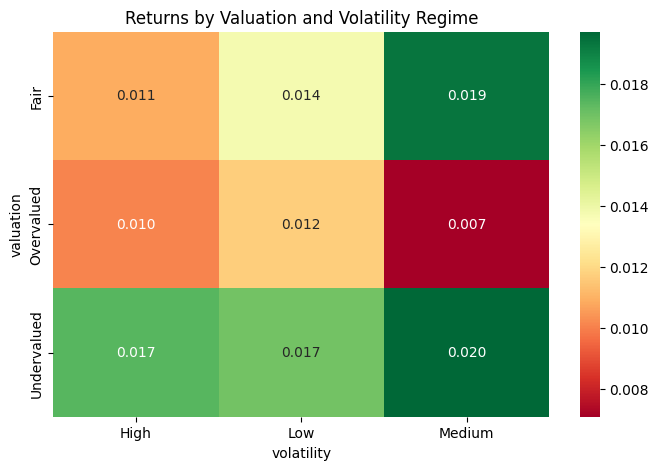

In [13]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

tickers = [
"RELIANCE.NS","TCS.NS","INFY.NS","HDFCBANK.NS","ICICIBANK.NS",
"HINDUNILVR.NS","ITC.NS","LT.NS","SBIN.NS","BHARTIARTL.NS",
"AXISBANK.NS","KOTAKBANK.NS","ASIANPAINT.NS","BAJFINANCE.NS",
"MARUTI.NS","TITAN.NS","SUNPHARMA.NS","ULTRACEMCO.NS"
]

records = []

for ticker in tickers:

    print("Testing:", ticker)

    stock = yf.Ticker(ticker)

    df = stock.history(period="5y")

    if df.empty:
        continue

    df["returns"] = df["Close"].pct_change()

    # volatility
    df["volatility"] = df["returns"].rolling(10).std()

    vol_low = df["volatility"].quantile(0.33)
    vol_high = df["volatility"].quantile(0.66)

    # forward return (20 days)
    df["future_return"] = df["Close"].shift(-20) / df["Close"] - 1

    info = stock.info

    eps = info.get("trailingEps")

    if eps is None:
        continue

    growth = info.get("earningsQuarterlyGrowth")

    if growth is None:
        growth = 0.05

    g = min(growth*100,15)

    intrinsic = eps * (8.5 + 2*g)

    df = df.dropna()

    for i,row in df.iterrows():

        price = row["Close"]

        # valuation classification
        if price < intrinsic * 0.8:
            valuation = "Undervalued"

        elif price > intrinsic * 1.2:
            valuation = "Overvalued"

        else:
            valuation = "Fair"

        # volatility classification
        if row["volatility"] < vol_low:
            vol = "Low"

        elif row["volatility"] > vol_high:
            vol = "High"

        else:
            vol = "Medium"

        records.append({
            "valuation": valuation,
            "volatility": vol,
            "return": row["future_return"]
        })

data = pd.DataFrame(records)

# heatmap table
table = data.groupby(["valuation","volatility"])["return"].mean().unstack()

print("\nAverage Forward Returns\n")
print(table)

# heatmap plot
plt.figure(figsize=(8,5))
sns.heatmap(table, annot=True, fmt=".3f", cmap="RdYlGn")
plt.title("Returns by Valuation and Volatility Regime")
plt.show()

In [16]:
import yfinance as yf
import pandas as pd
import numpy as np

# ---------- Settings ----------

initial_capital = 100000
capital = initial_capital

tickers = [
"RELIANCE.NS","TCS.NS","INFY.NS","HDFCBANK.NS","ICICIBANK.NS",
"HINDUNILVR.NS","ITC.NS","LT.NS","SBIN.NS","BHARTIARTL.NS",
"AXISBANK.NS","KOTAKBANK.NS","ASIANPAINT.NS","BAJFINANCE.NS",
"MARUTI.NS","TITAN.NS","SUNPHARMA.NS","ULTRACEMCO.NS"
]

trade_log = []

# ---------- UT Bot Logic ----------

def compute_utbot(df, atr_period=10, multiplier=1):

    df["tr"] = np.maximum(
        df["High"] - df["Low"],
        np.maximum(
            abs(df["High"] - df["Close"].shift()),
            abs(df["Low"] - df["Close"].shift())
        )
    )

    df["atr"] = df["tr"].rolling(atr_period).mean()

    df["upper"] = df["Close"] - multiplier * df["atr"]
    df["lower"] = df["Close"] + multiplier * df["atr"]

    trend = [1]

    for i in range(1,len(df)):

        if df["Close"].iloc[i] > df["lower"].iloc[i-1]:
            trend.append(1)

        elif df["Close"].iloc[i] < df["upper"].iloc[i-1]:
            trend.append(-1)

        else:
            trend.append(trend[-1])

    df["trend"] = trend

    df["buy"] = (df["trend"] == 1) & (df["trend"].shift() == -1)
    df["sell"] = (df["trend"] == -1) & (df["trend"].shift() == 1)

    return df


# ---------- Backtest ----------

for ticker in tickers:

    print("Testing:", ticker)

    stock = yf.Ticker(ticker)

    df = stock.history(period="1y")

    if df.empty:
        continue

    df = compute_utbot(df)

    # ---------- Graham Valuation ----------

    info = stock.info

    eps = info.get("trailingEps")

    if eps is None:
        continue

    growth = info.get("earningsQuarterlyGrowth")

    if growth is None:
        growth = 0.05

    g = min(growth*100,15)

    intrinsic = eps * (8.5 + 2*g)

    position = False
    shares = 0

    for i,row in df.iterrows():

        price = row["Close"]

        # BUY condition
        if not position and row["buy"]:

            if price < intrinsic:

                shares = capital / price
                entry_price = price
                position = True

        # SELL condition
        elif position and row["sell"]:

            exit_price = price

            capital = shares * exit_price

            profit = capital - shares * entry_price

            trade_log.append({
                "Stock": ticker,
                "Entry": entry_price,
                "Exit": exit_price,
                "Profit": profit
            })

            position = False


# ---------- Results ----------

trades = pd.DataFrame(trade_log)

print("\nTotal Trades:", len(trades))

if len(trades) > 0:

    wins = trades[trades["Profit"] > 0]

    print("Win Rate:", len(wins)/len(trades))

print("\nInitial Capital:", initial_capital)
print("Final Capital:", capital)

print("Total Return %:", (capital/initial_capital - 1)*100)

print("\nSample Trades:")
print(trades)

Testing: RELIANCE.NS
Testing: TCS.NS
Testing: INFY.NS
Testing: HDFCBANK.NS
Testing: ICICIBANK.NS
Testing: HINDUNILVR.NS
Testing: ITC.NS
Testing: LT.NS
Testing: SBIN.NS
Testing: BHARTIARTL.NS
Testing: AXISBANK.NS
Testing: KOTAKBANK.NS
Testing: ASIANPAINT.NS
Testing: BAJFINANCE.NS
Testing: MARUTI.NS
Testing: TITAN.NS
Testing: SUNPHARMA.NS
Testing: ULTRACEMCO.NS

Total Trades: 28
Win Rate: 0.42857142857142855

Initial Capital: 100000
Final Capital: 140064.45273196843
Total Return %: 40.06445273196844

Sample Trades:
           Stock        Entry         Exit        Profit
0    HDFCBANK.NS   891.326965   932.248779   4591.111405
1    HDFCBANK.NS   965.548706   948.479370  -1849.001304
2    HDFCBANK.NS   976.155273   990.535034   1513.495856
3    HDFCBANK.NS   997.767029   984.950012  -1339.236308
4    HDFCBANK.NS   965.250000   994.750000   3145.333235
5    HDFCBANK.NS  1008.849976   977.500000  -3295.863485
6    HDFCBANK.NS   948.700012   857.049988  -9927.787044
7        SBIN.NS   753.47

In [18]:
import yfinance as yf
import pandas as pd
import numpy as np

# ---------- Initial capital ----------
initial_capital = 100000
capital = initial_capital

# ---------- 100+ Indian Stocks ----------
tickers = [

"HDFCBANK.NS","ICICIBANK.NS","KOTAKBANK.NS","AXISBANK.NS","SBIN.NS",
"BAJFINANCE.NS","BAJAJFINSV.NS","INDUSINDBK.NS","HDFCLIFE.NS","SBILIFE.NS",

"TCS.NS","INFY.NS","HCLTECH.NS","WIPRO.NS","TECHM.NS",
"LTIM.NS","MPHASIS.NS","COFORGE.NS","PERSISTENT.NS","LTI.NS",

"RELIANCE.NS","ONGC.NS","BPCL.NS","IOC.NS","GAIL.NS",
"POWERGRID.NS","NTPC.NS","ADANIGREEN.NS","ADANIPOWER.NS","TATAPOWER.NS",

"HINDUNILVR.NS","ITC.NS","NESTLEIND.NS","BRITANNIA.NS","DABUR.NS",
"GODREJCP.NS","MARICO.NS","COLPAL.NS","PGHH.NS","VBL.NS",

"SUNPHARMA.NS","DRREDDY.NS","DIVISLAB.NS","CIPLA.NS","LUPIN.NS",
"TORNTPHARM.NS","AUROPHARMA.NS","ALKEM.NS","BIOCON.NS","GLENMARK.NS",

"MARUTI.NS","TATAMOTORS.NS","M&M.NS","EICHERMOT.NS","BAJAJ-AUTO.NS",
"HEROMOTOCO.NS","ASHOKLEY.NS","TVSMOTOR.NS","ESCORTS.NS","SONACOMS.NS",

"LT.NS","SIEMENS.NS","ABB.NS","CUMMINSIND.NS","HAVELLS.NS",
"POLYCAB.NS","BOSCHLTD.NS","AIAENG.NS","THERMAX.NS","SKFINDIA.NS",

"TATASTEEL.NS","JSWSTEEL.NS","HINDALCO.NS","VEDL.NS","SAIL.NS",
"NMDC.NS","JINDALSTEL.NS","NATIONALUM.NS","HINDZINC.NS","APLAPOLLO.NS",

"ULTRACEMCO.NS","SHREECEM.NS","AMBUJACEM.NS","ACC.NS","DALBHARAT.NS",

"TITAN.NS","TRENT.NS","DMART.NS","ADANIENT.NS","PAGEIND.NS",

"BHARTIARTL.NS","IDEA.NS","ZEEL.NS","SUNTV.NS","INDIGO.NS"
]

trade_log = []

# ---------- UT Bot Function ----------
def compute_utbot(df, atr_period=10, multiplier=1):

    df["tr"] = np.maximum(
        df["High"] - df["Low"],
        np.maximum(
            abs(df["High"] - df["Close"].shift()),
            abs(df["Low"] - df["Close"].shift())
        )
    )

    df["atr"] = df["tr"].rolling(atr_period).mean()

    df["upper"] = df["Close"] - multiplier * df["atr"]
    df["lower"] = df["Close"] + multiplier * df["atr"]

    trend = [1]

    for i in range(1,len(df)):

        if df["Close"].iloc[i] > df["lower"].iloc[i-1]:
            trend.append(1)

        elif df["Close"].iloc[i] < df["upper"].iloc[i-1]:
            trend.append(-1)

        else:
            trend.append(trend[-1])

    df["trend"] = trend

    df["buy"] = (df["trend"] == 1) & (df["trend"].shift() == -1)
    df["sell"] = (df["trend"] == -1) & (df["trend"].shift() == 1)

    return df


# ---------- Backtest ----------
for ticker in tickers:

    print("Testing:", ticker)

    stock = yf.Ticker(ticker)

    df = stock.history(period="5y")

    if df.empty:
        continue

    df = compute_utbot(df)

    info = stock.info

    eps = info.get("trailingEps")

    if eps is None:
        continue

    growth = info.get("earningsQuarterlyGrowth")

    if growth is None:
        growth = 0.05

    g = min(growth * 100, 15)

    intrinsic = eps * (8.5 + 2 * g)

    position = False
    shares = 0

    for i,row in df.iterrows():

        price = row["Close"]

        # BUY
        if not position and row["buy"]:

            if price < intrinsic:

                shares = capital / price
                entry_price = price
                position = True


        # SELL
        elif position and row["sell"]:

            exit_price = price

            capital = shares * exit_price

            profit = capital - (shares * entry_price)

            trade_log.append({
                "Stock": ticker,
                "Entry": entry_price,
                "Exit": exit_price,
                "Profit": profit
            })

            position = False


# ---------- Results ----------
trades = pd.DataFrame(trade_log)

print("\nTotal Trades:", len(trades))

if len(trades) > 0:

    wins = trades[trades["Profit"] > 0]

    print("Win Rate:", len(wins) / len(trades))

print("\nInitial Capital:", initial_capital)

print("Final Capital:", capital)

print("Total Return %:", (capital/initial_capital - 1)*100)

print("\nSample Trades:")

print(trades)

Testing: HDFCBANK.NS
Testing: ICICIBANK.NS
Testing: KOTAKBANK.NS
Testing: AXISBANK.NS
Testing: SBIN.NS
Testing: BAJFINANCE.NS
Testing: BAJAJFINSV.NS
Testing: INDUSINDBK.NS
Testing: HDFCLIFE.NS
Testing: SBILIFE.NS
Testing: TCS.NS
Testing: INFY.NS
Testing: HCLTECH.NS
Testing: WIPRO.NS
Testing: TECHM.NS
Testing: LTIM.NS
Testing: MPHASIS.NS
Testing: COFORGE.NS
Testing: PERSISTENT.NS
Testing: LTI.NS


$LTI.NS: possibly delisted; no price data found  (period=5y) (Yahoo error = "No data found, symbol may be delisted")


Testing: RELIANCE.NS
Testing: ONGC.NS
Testing: BPCL.NS
Testing: IOC.NS
Testing: GAIL.NS
Testing: POWERGRID.NS
Testing: NTPC.NS
Testing: ADANIGREEN.NS
Testing: ADANIPOWER.NS
Testing: TATAPOWER.NS
Testing: HINDUNILVR.NS
Testing: ITC.NS
Testing: NESTLEIND.NS
Testing: BRITANNIA.NS
Testing: DABUR.NS
Testing: GODREJCP.NS
Testing: MARICO.NS
Testing: COLPAL.NS
Testing: PGHH.NS
Testing: VBL.NS
Testing: SUNPHARMA.NS
Testing: DRREDDY.NS
Testing: DIVISLAB.NS
Testing: CIPLA.NS
Testing: LUPIN.NS
Testing: TORNTPHARM.NS
Testing: AUROPHARMA.NS
Testing: ALKEM.NS
Testing: BIOCON.NS
Testing: GLENMARK.NS
Testing: MARUTI.NS
Testing: TATAMOTORS.NS


$TATAMOTORS.NS: possibly delisted; no price data found  (period=5y) (Yahoo error = "No data found, symbol may be delisted")


Testing: M&M.NS
Testing: EICHERMOT.NS
Testing: BAJAJ-AUTO.NS
Testing: HEROMOTOCO.NS
Testing: ASHOKLEY.NS
Testing: TVSMOTOR.NS
Testing: ESCORTS.NS
Testing: SONACOMS.NS
Testing: LT.NS
Testing: SIEMENS.NS
Testing: ABB.NS
Testing: CUMMINSIND.NS
Testing: HAVELLS.NS
Testing: POLYCAB.NS
Testing: BOSCHLTD.NS
Testing: AIAENG.NS
Testing: THERMAX.NS
Testing: SKFINDIA.NS
Testing: TATASTEEL.NS
Testing: JSWSTEEL.NS
Testing: HINDALCO.NS
Testing: VEDL.NS
Testing: SAIL.NS
Testing: NMDC.NS
Testing: JINDALSTEL.NS
Testing: NATIONALUM.NS
Testing: HINDZINC.NS
Testing: APLAPOLLO.NS
Testing: ULTRACEMCO.NS
Testing: SHREECEM.NS
Testing: AMBUJACEM.NS
Testing: ACC.NS
Testing: DALBHARAT.NS
Testing: TITAN.NS
Testing: TRENT.NS
Testing: DMART.NS
Testing: ADANIENT.NS
Testing: PAGEIND.NS
Testing: BHARTIARTL.NS
Testing: IDEA.NS
Testing: ZEEL.NS
Testing: SUNTV.NS
Testing: INDIGO.NS

Total Trades: 1246
Win Rate: 0.5008025682182986

Initial Capital: 100000
Final Capital: 2877616923377864.0
Total Return %: 2877616923277.864

Testing: HDFCBANK.NS
Testing: ICICIBANK.NS
Testing: KOTAKBANK.NS
Testing: AXISBANK.NS
Testing: SBIN.NS
Testing: BAJFINANCE.NS
Testing: BAJAJFINSV.NS
Testing: INDUSINDBK.NS
Testing: HDFCLIFE.NS
Testing: SBILIFE.NS
Testing: TCS.NS
Testing: INFY.NS
Testing: HCLTECH.NS
Testing: WIPRO.NS
Testing: TECHM.NS
Testing: LTIM.NS
Testing: MPHASIS.NS
Testing: COFORGE.NS
Testing: PERSISTENT.NS
Testing: LTI.NS


$LTI.NS: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")


Testing: RELIANCE.NS
Testing: ONGC.NS
Testing: BPCL.NS
Testing: IOC.NS
Testing: GAIL.NS
Testing: POWERGRID.NS
Testing: NTPC.NS
Testing: ADANIGREEN.NS
Testing: ADANIPOWER.NS
Testing: TATAPOWER.NS
Testing: HINDUNILVR.NS
Testing: ITC.NS
Testing: NESTLEIND.NS
Testing: BRITANNIA.NS
Testing: DABUR.NS
Testing: GODREJCP.NS
Testing: MARICO.NS
Testing: COLPAL.NS
Testing: PGHH.NS
Testing: VBL.NS
Testing: SUNPHARMA.NS
Testing: DRREDDY.NS
Testing: DIVISLAB.NS
Testing: CIPLA.NS
Testing: LUPIN.NS
Testing: TORNTPHARM.NS
Testing: AUROPHARMA.NS
Testing: ALKEM.NS
Testing: BIOCON.NS
Testing: GLENMARK.NS
Testing: MARUTI.NS
Testing: TATAMOTORS.NS


$TATAMOTORS.NS: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")


Testing: M&M.NS
Testing: EICHERMOT.NS
Testing: BAJAJ-AUTO.NS
Testing: HEROMOTOCO.NS
Testing: ASHOKLEY.NS
Testing: TVSMOTOR.NS
Testing: ESCORTS.NS
Testing: SONACOMS.NS
Testing: LT.NS
Testing: SIEMENS.NS
Testing: ABB.NS
Testing: CUMMINSIND.NS
Testing: HAVELLS.NS
Testing: POLYCAB.NS
Testing: BOSCHLTD.NS
Testing: AIAENG.NS
Testing: THERMAX.NS
Testing: SKFINDIA.NS
Testing: TATASTEEL.NS
Testing: JSWSTEEL.NS
Testing: HINDALCO.NS
Testing: VEDL.NS
Testing: SAIL.NS
Testing: NMDC.NS
Testing: JINDALSTEL.NS
Testing: NATIONALUM.NS
Testing: HINDZINC.NS
Testing: APLAPOLLO.NS
Testing: ULTRACEMCO.NS
Testing: SHREECEM.NS
Testing: AMBUJACEM.NS
Testing: ACC.NS
Testing: DALBHARAT.NS
Testing: TITAN.NS
Testing: TRENT.NS
Testing: DMART.NS
Testing: ADANIENT.NS
Testing: PAGEIND.NS
Testing: BHARTIARTL.NS
Testing: IDEA.NS
Testing: ZEEL.NS
Testing: SUNTV.NS
Testing: INDIGO.NS

Total Trades: 185
Win Rate: 0.5081081081081081

Initial Capital: 100000
Final Capital: 506062.9308348319
Total Return %: 406.0629308348319


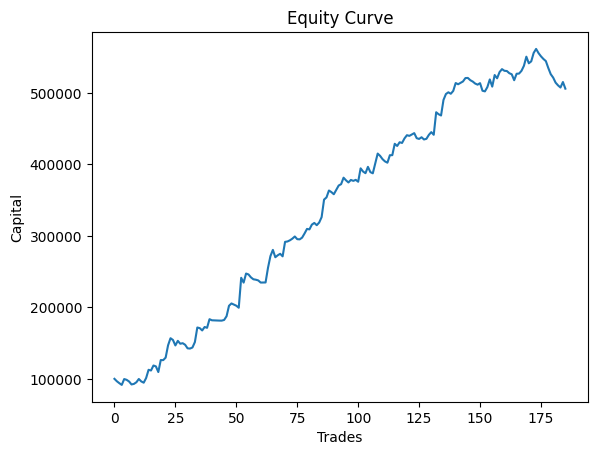


Average Return per Trade: 2.1949347612693617
Best Trade: 41912.012884135416
Worst Trade: -10649.92147105967


In [20]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------- SETTINGS ----------
initial_capital = 100000
trade_size = 100000   # fixed investment per trade

tickers = [

"HDFCBANK.NS","ICICIBANK.NS","KOTAKBANK.NS","AXISBANK.NS","SBIN.NS",
"BAJFINANCE.NS","BAJAJFINSV.NS","INDUSINDBK.NS","HDFCLIFE.NS","SBILIFE.NS",

"TCS.NS","INFY.NS","HCLTECH.NS","WIPRO.NS","TECHM.NS",
"LTIM.NS","MPHASIS.NS","COFORGE.NS","PERSISTENT.NS","LTI.NS",

"RELIANCE.NS","ONGC.NS","BPCL.NS","IOC.NS","GAIL.NS",
"POWERGRID.NS","NTPC.NS","ADANIGREEN.NS","ADANIPOWER.NS","TATAPOWER.NS",

"HINDUNILVR.NS","ITC.NS","NESTLEIND.NS","BRITANNIA.NS","DABUR.NS",
"GODREJCP.NS","MARICO.NS","COLPAL.NS","PGHH.NS","VBL.NS",

"SUNPHARMA.NS","DRREDDY.NS","DIVISLAB.NS","CIPLA.NS","LUPIN.NS",
"TORNTPHARM.NS","AUROPHARMA.NS","ALKEM.NS","BIOCON.NS","GLENMARK.NS",

"MARUTI.NS","TATAMOTORS.NS","M&M.NS","EICHERMOT.NS","BAJAJ-AUTO.NS",
"HEROMOTOCO.NS","ASHOKLEY.NS","TVSMOTOR.NS","ESCORTS.NS","SONACOMS.NS",

"LT.NS","SIEMENS.NS","ABB.NS","CUMMINSIND.NS","HAVELLS.NS",
"POLYCAB.NS","BOSCHLTD.NS","AIAENG.NS","THERMAX.NS","SKFINDIA.NS",

"TATASTEEL.NS","JSWSTEEL.NS","HINDALCO.NS","VEDL.NS","SAIL.NS",
"NMDC.NS","JINDALSTEL.NS","NATIONALUM.NS","HINDZINC.NS","APLAPOLLO.NS",

"ULTRACEMCO.NS","SHREECEM.NS","AMBUJACEM.NS","ACC.NS","DALBHARAT.NS",

"TITAN.NS","TRENT.NS","DMART.NS","ADANIENT.NS","PAGEIND.NS",

"BHARTIARTL.NS","IDEA.NS","ZEEL.NS","SUNTV.NS","INDIGO.NS"
]

trade_log = []

# ---------- UT BOT ----------
def compute_utbot(df, atr_period=10, multiplier=1):

    df["tr"] = np.maximum(
        df["High"] - df["Low"],
        np.maximum(
            abs(df["High"] - df["Close"].shift()),
            abs(df["Low"] - df["Close"].shift())
        )
    )

    df["atr"] = df["tr"].rolling(atr_period).mean()

    df["upper"] = df["Close"] - multiplier * df["atr"]
    df["lower"] = df["Close"] + multiplier * df["atr"]

    trend = [1]

    for i in range(1, len(df)):
        if df["Close"].iloc[i] > df["lower"].iloc[i-1]:
            trend.append(1)
        elif df["Close"].iloc[i] < df["upper"].iloc[i-1]:
            trend.append(-1)
        else:
            trend.append(trend[-1])

    df["trend"] = trend

    df["buy"] = (df["trend"] == 1) & (df["trend"].shift() == -1)
    df["sell"] = (df["trend"] == -1) & (df["trend"].shift() == 1)

    return df


# ---------- BACKTEST ----------
for ticker in tickers:

    print("Testing:", ticker)

    stock = yf.Ticker(ticker)
    df = stock.history(period="1y")

    if df.empty:
        continue

    df = compute_utbot(df)

    info = stock.info
    eps = info.get("trailingEps")

    if eps is None:
        continue

    growth = info.get("earningsQuarterlyGrowth")
    if growth is None:
        growth = 0.05

    g = min(growth * 100, 15)
    intrinsic = eps * (8.5 + 2 * g)

    position = False
    shares = 0

    for i, row in df.iterrows():

        price = row["Close"]

        # BUY
        if not position and row["buy"]:
            if price < intrinsic:
                shares = trade_size / price
                entry_price = price
                entry_date = i
                position = True

        # SELL
        elif position and row["sell"]:

            exit_price = price
            exit_date = i

            profit = (exit_price - entry_price) * shares

            trade_log.append({
                "Stock": ticker,
                "Entry Date": entry_date,
                "Exit Date": exit_date,
                "Entry": entry_price,
                "Exit": exit_price,
                "Profit": profit,
                "Return %": (exit_price / entry_price - 1) * 100
            })

            position = False


# ---------- RESULTS ----------
trades = pd.DataFrame(trade_log)

print("\nTotal Trades:", len(trades))

if len(trades) > 0:
    win_rate = len(trades[trades["Profit"] > 0]) / len(trades)
    print("Win Rate:", win_rate)

total_profit = trades["Profit"].sum()
final_capital = initial_capital + total_profit

print("\nInitial Capital:", initial_capital)
print("Final Capital:", final_capital)
print("Total Return %:", (final_capital / initial_capital - 1) * 100)

# ---------- EQUITY CURVE ----------
trades = trades.sort_values("Exit Date")

equity = [initial_capital]

for p in trades["Profit"]:
    equity.append(equity[-1] + p)

plt.figure()
plt.plot(equity)
plt.title("Equity Curve")
plt.xlabel("Trades")
plt.ylabel("Capital")
plt.show()

# ---------- EXTRA STATS ----------
print("\nAverage Return per Trade:", trades["Return %"].mean())
print("Best Trade:", trades["Profit"].max())
print("Worst Trade:", trades["Profit"].min())

Testing: HDFCBANK.NS
Testing: ICICIBANK.NS
Testing: KOTAKBANK.NS
Testing: AXISBANK.NS
Testing: SBIN.NS
Testing: BAJFINANCE.NS
Testing: BAJAJFINSV.NS
Testing: INDUSINDBK.NS
Testing: HDFCLIFE.NS
Testing: SBILIFE.NS
Testing: TCS.NS
Testing: INFY.NS
Testing: HCLTECH.NS
Testing: WIPRO.NS
Testing: TECHM.NS
Testing: LTIM.NS
Testing: MPHASIS.NS
Testing: COFORGE.NS
Testing: PERSISTENT.NS
Testing: LTI.NS


$LTI.NS: possibly delisted; no price data found  (period=5y) (Yahoo error = "No data found, symbol may be delisted")


Testing: RELIANCE.NS
Testing: ONGC.NS
Testing: BPCL.NS
Testing: IOC.NS
Testing: GAIL.NS
Testing: POWERGRID.NS
Testing: NTPC.NS
Testing: ADANIGREEN.NS
Testing: ADANIPOWER.NS
Testing: TATAPOWER.NS
Testing: HINDUNILVR.NS
Testing: ITC.NS
Testing: NESTLEIND.NS
Testing: BRITANNIA.NS
Testing: DABUR.NS
Testing: GODREJCP.NS
Testing: MARICO.NS
Testing: COLPAL.NS
Testing: PGHH.NS
Testing: VBL.NS
Testing: SUNPHARMA.NS
Testing: DRREDDY.NS
Testing: DIVISLAB.NS
Testing: CIPLA.NS
Testing: LUPIN.NS
Testing: TORNTPHARM.NS
Testing: AUROPHARMA.NS
Testing: ALKEM.NS
Testing: BIOCON.NS
Testing: GLENMARK.NS
Testing: MARUTI.NS
Testing: TATAMOTORS.NS


$TATAMOTORS.NS: possibly delisted; no price data found  (period=5y) (Yahoo error = "No data found, symbol may be delisted")


Testing: M&M.NS
Testing: EICHERMOT.NS
Testing: BAJAJ-AUTO.NS
Testing: HEROMOTOCO.NS
Testing: ASHOKLEY.NS
Testing: TVSMOTOR.NS
Testing: ESCORTS.NS
Testing: SONACOMS.NS
Testing: LT.NS
Testing: SIEMENS.NS
Testing: ABB.NS
Testing: CUMMINSIND.NS
Testing: HAVELLS.NS
Testing: POLYCAB.NS
Testing: BOSCHLTD.NS
Testing: AIAENG.NS
Testing: THERMAX.NS
Testing: SKFINDIA.NS
Testing: TATASTEEL.NS
Testing: JSWSTEEL.NS
Testing: HINDALCO.NS
Testing: VEDL.NS
Testing: SAIL.NS
Testing: NMDC.NS
Testing: JINDALSTEL.NS
Testing: NATIONALUM.NS
Testing: HINDZINC.NS
Testing: APLAPOLLO.NS
Testing: ULTRACEMCO.NS
Testing: SHREECEM.NS
Testing: AMBUJACEM.NS
Testing: ACC.NS
Testing: DALBHARAT.NS
Testing: TITAN.NS
Testing: TRENT.NS
Testing: DMART.NS
Testing: ADANIENT.NS
Testing: PAGEIND.NS
Testing: BHARTIARTL.NS
Testing: IDEA.NS
Testing: ZEEL.NS
Testing: SUNTV.NS
Testing: INDIGO.NS

Total Trades: 1246
Win Rate: 0.48314606741573035

Initial Capital: 100000
Final Capital: 2949985.52549797
Total Return %: 2849.9855254979702

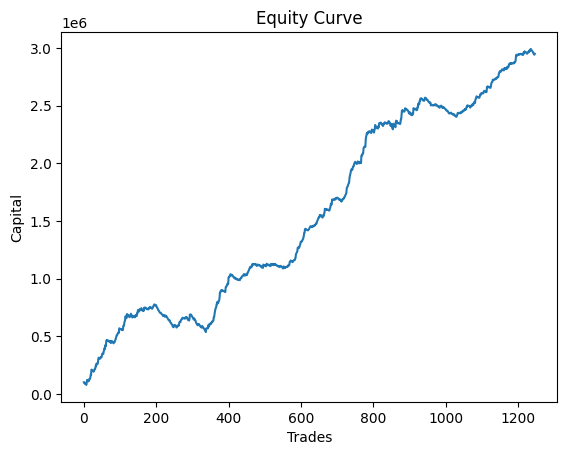


Average Win: 9022.360086037617
Average Loss: -4008.501935243287
Risk Reward Ratio: 2.250805969859168

Best Trade: 65040.11632585576
Worst Trade: -21974.88302513879

Exit Reason Breakdown:
Exit Reason
UT Sell      1009
Stop Loss     237
Name: count, dtype: int64


In [21]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------- SETTINGS ----------
initial_capital = 100000
trade_size = 100000
stop_loss_pct = 0.05   # 5% stop loss

tickers = [

"HDFCBANK.NS","ICICIBANK.NS","KOTAKBANK.NS","AXISBANK.NS","SBIN.NS",
"BAJFINANCE.NS","BAJAJFINSV.NS","INDUSINDBK.NS","HDFCLIFE.NS","SBILIFE.NS",

"TCS.NS","INFY.NS","HCLTECH.NS","WIPRO.NS","TECHM.NS",
"LTIM.NS","MPHASIS.NS","COFORGE.NS","PERSISTENT.NS","LTI.NS",

"RELIANCE.NS","ONGC.NS","BPCL.NS","IOC.NS","GAIL.NS",
"POWERGRID.NS","NTPC.NS","ADANIGREEN.NS","ADANIPOWER.NS","TATAPOWER.NS",

"HINDUNILVR.NS","ITC.NS","NESTLEIND.NS","BRITANNIA.NS","DABUR.NS",
"GODREJCP.NS","MARICO.NS","COLPAL.NS","PGHH.NS","VBL.NS",

"SUNPHARMA.NS","DRREDDY.NS","DIVISLAB.NS","CIPLA.NS","LUPIN.NS",
"TORNTPHARM.NS","AUROPHARMA.NS","ALKEM.NS","BIOCON.NS","GLENMARK.NS",

"MARUTI.NS","TATAMOTORS.NS","M&M.NS","EICHERMOT.NS","BAJAJ-AUTO.NS",
"HEROMOTOCO.NS","ASHOKLEY.NS","TVSMOTOR.NS","ESCORTS.NS","SONACOMS.NS",

"LT.NS","SIEMENS.NS","ABB.NS","CUMMINSIND.NS","HAVELLS.NS",
"POLYCAB.NS","BOSCHLTD.NS","AIAENG.NS","THERMAX.NS","SKFINDIA.NS",

"TATASTEEL.NS","JSWSTEEL.NS","HINDALCO.NS","VEDL.NS","SAIL.NS",
"NMDC.NS","JINDALSTEL.NS","NATIONALUM.NS","HINDZINC.NS","APLAPOLLO.NS",

"ULTRACEMCO.NS","SHREECEM.NS","AMBUJACEM.NS","ACC.NS","DALBHARAT.NS",

"TITAN.NS","TRENT.NS","DMART.NS","ADANIENT.NS","PAGEIND.NS",

"BHARTIARTL.NS","IDEA.NS","ZEEL.NS","SUNTV.NS","INDIGO.NS"
]

trade_log = []

# ---------- UT BOT ----------
def compute_utbot(df, atr_period=10, multiplier=1):

    df["tr"] = np.maximum(
        df["High"] - df["Low"],
        np.maximum(
            abs(df["High"] - df["Close"].shift()),
            abs(df["Low"] - df["Close"].shift())
        )
    )

    df["atr"] = df["tr"].rolling(atr_period).mean()

    df["upper"] = df["Close"] - multiplier * df["atr"]
    df["lower"] = df["Close"] + multiplier * df["atr"]

    trend = [1]

    for i in range(1, len(df)):
        if df["Close"].iloc[i] > df["lower"].iloc[i-1]:
            trend.append(1)
        elif df["Close"].iloc[i] < df["upper"].iloc[i-1]:
            trend.append(-1)
        else:
            trend.append(trend[-1])

    df["trend"] = trend

    df["buy"] = (df["trend"] == 1) & (df["trend"].shift() == -1)
    df["sell"] = (df["trend"] == -1) & (df["trend"].shift() == 1)

    return df


# ---------- BACKTEST ----------
for ticker in tickers:

    print("Testing:", ticker)

    stock = yf.Ticker(ticker)
    df = stock.history(period="5y")

    if df.empty:
        continue

    df = compute_utbot(df)

    info = stock.info
    eps = info.get("trailingEps")

    if eps is None:
        continue

    growth = info.get("earningsQuarterlyGrowth")
    if growth is None:
        growth = 0.05

    g = min(growth * 100, 15)
    intrinsic = eps * (8.5 + 2 * g)

    position = False
    shares = 0

    for i, row in df.iterrows():

        price = row["Close"]

        # ---------- BUY ----------
        if not position and row["buy"]:
            if price < intrinsic:
                shares = trade_size / price
                entry_price = price
                entry_date = i
                position = True

        # ---------- SELL ----------
        elif position:

            stop_price = entry_price * (1 - stop_loss_pct)

            # STOP LOSS
            if price <= stop_price:
                exit_price = price
                exit_reason = "Stop Loss"

            # UT BOT SELL
            elif row["sell"]:
                exit_price = price
                exit_reason = "UT Sell"

            else:
                continue

            exit_date = i

            profit = (exit_price - entry_price) * shares

            trade_log.append({
                "Stock": ticker,
                "Entry Date": entry_date,
                "Exit Date": exit_date,
                "Entry": entry_price,
                "Exit": exit_price,
                "Profit": profit,
                "Return %": (exit_price / entry_price - 1) * 100,
                "Exit Reason": exit_reason
            })

            position = False


# ---------- RESULTS ----------
trades = pd.DataFrame(trade_log)

print("\nTotal Trades:", len(trades))

if len(trades) > 0:
    win_rate = len(trades[trades["Profit"] > 0]) / len(trades)
    print("Win Rate:", win_rate)

total_profit = trades["Profit"].sum()
final_capital = initial_capital + total_profit

print("\nInitial Capital:", initial_capital)
print("Final Capital:", final_capital)
print("Total Return %:", (final_capital / initial_capital - 1) * 100)

# ---------- EQUITY CURVE ----------
trades = trades.sort_values("Exit Date")

equity = [initial_capital]

for p in trades["Profit"]:
    equity.append(equity[-1] + p)

plt.figure()
plt.plot(equity)
plt.title("Equity Curve")
plt.xlabel("Trades")
plt.ylabel("Capital")
plt.show()

# ---------- RISK / REWARD ----------
avg_win = trades[trades["Profit"] > 0]["Profit"].mean()
avg_loss = trades[trades["Profit"] < 0]["Profit"].mean()

print("\nAverage Win:", avg_win)
print("Average Loss:", avg_loss)

if avg_loss != 0:
    print("Risk Reward Ratio:", abs(avg_win / avg_loss))

# ---------- EXTRA ----------
print("\nBest Trade:", trades["Profit"].max())
print("Worst Trade:", trades["Profit"].min())

print("\nExit Reason Breakdown:")
print(trades["Exit Reason"].value_counts())

Testing: HDFCBANK.NS
Testing: ICICIBANK.NS
Testing: KOTAKBANK.NS
Testing: AXISBANK.NS
Testing: SBIN.NS
Testing: BAJFINANCE.NS
Testing: BAJAJFINSV.NS
Testing: INDUSINDBK.NS
Testing: HDFCLIFE.NS
Testing: SBILIFE.NS
Testing: TCS.NS
Testing: INFY.NS
Testing: HCLTECH.NS
Testing: WIPRO.NS
Testing: TECHM.NS
Testing: LTIM.NS
Testing: MPHASIS.NS
Testing: COFORGE.NS
Testing: PERSISTENT.NS
Testing: LTI.NS


$LTI.NS: possibly delisted; no price data found  (period=5y) (Yahoo error = "No data found, symbol may be delisted")


Testing: RELIANCE.NS
Testing: ONGC.NS
Testing: BPCL.NS
Testing: IOC.NS
Testing: GAIL.NS
Testing: POWERGRID.NS
Testing: NTPC.NS
Testing: ADANIGREEN.NS
Testing: ADANIPOWER.NS
Testing: TATAPOWER.NS
Testing: HINDUNILVR.NS
Testing: ITC.NS
Testing: NESTLEIND.NS
Testing: BRITANNIA.NS
Testing: DABUR.NS
Testing: GODREJCP.NS
Testing: MARICO.NS
Testing: COLPAL.NS
Testing: PGHH.NS
Testing: VBL.NS
Testing: SUNPHARMA.NS
Testing: DRREDDY.NS
Testing: DIVISLAB.NS
Testing: CIPLA.NS
Testing: LUPIN.NS
Testing: TORNTPHARM.NS
Testing: AUROPHARMA.NS
Testing: ALKEM.NS
Testing: BIOCON.NS
Testing: GLENMARK.NS
Testing: MARUTI.NS
Testing: TATAMOTORS.NS


$TATAMOTORS.NS: possibly delisted; no price data found  (period=5y) (Yahoo error = "No data found, symbol may be delisted")


Testing: M&M.NS
Testing: EICHERMOT.NS
Testing: BAJAJ-AUTO.NS
Testing: HEROMOTOCO.NS
Testing: ASHOKLEY.NS
Testing: TVSMOTOR.NS
Testing: ESCORTS.NS
Testing: SONACOMS.NS
Testing: LT.NS
Testing: SIEMENS.NS
Testing: ABB.NS
Testing: CUMMINSIND.NS
Testing: HAVELLS.NS
Testing: POLYCAB.NS
Testing: BOSCHLTD.NS
Testing: AIAENG.NS
Testing: THERMAX.NS
Testing: SKFINDIA.NS
Testing: TATASTEEL.NS
Testing: JSWSTEEL.NS
Testing: HINDALCO.NS
Testing: VEDL.NS
Testing: SAIL.NS
Testing: NMDC.NS
Testing: JINDALSTEL.NS
Testing: NATIONALUM.NS
Testing: HINDZINC.NS
Testing: APLAPOLLO.NS
Testing: ULTRACEMCO.NS
Testing: SHREECEM.NS
Testing: AMBUJACEM.NS
Testing: ACC.NS
Testing: DALBHARAT.NS
Testing: TITAN.NS
Testing: TRENT.NS
Testing: DMART.NS
Testing: ADANIENT.NS
Testing: PAGEIND.NS
Testing: BHARTIARTL.NS
Testing: IDEA.NS
Testing: ZEEL.NS
Testing: SUNTV.NS
Testing: INDIGO.NS

Total Trades: 1246
Win Rate: 0.48314606741573035

Initial Capital: 100000
Final Capital: 2949985.6997492453
Total Return %: 2849.98569974924

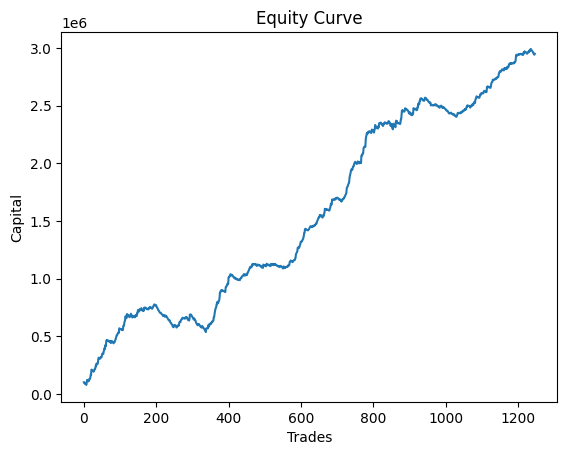


Average Win: 9022.360172326404
Average Loss: -4008.5017453280266
Risk Reward Ratio: 2.2508060980245572

Best Trade: 65040.11632585576
Worst Trade: -21974.88302513879

Exit Reason Breakdown:
Exit Reason
UT Sell      1009
Stop Loss     237
Name: count, dtype: int64


In [22]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------- SETTINGS ----------
initial_capital = 100000
trade_size = 100000
stop_loss_pct = 0.05   # 5% stop loss

tickers = [

"HDFCBANK.NS","ICICIBANK.NS","KOTAKBANK.NS","AXISBANK.NS","SBIN.NS",
"BAJFINANCE.NS","BAJAJFINSV.NS","INDUSINDBK.NS","HDFCLIFE.NS","SBILIFE.NS",

"TCS.NS","INFY.NS","HCLTECH.NS","WIPRO.NS","TECHM.NS",
"LTIM.NS","MPHASIS.NS","COFORGE.NS","PERSISTENT.NS","LTI.NS",

"RELIANCE.NS","ONGC.NS","BPCL.NS","IOC.NS","GAIL.NS",
"POWERGRID.NS","NTPC.NS","ADANIGREEN.NS","ADANIPOWER.NS","TATAPOWER.NS",

"HINDUNILVR.NS","ITC.NS","NESTLEIND.NS","BRITANNIA.NS","DABUR.NS",
"GODREJCP.NS","MARICO.NS","COLPAL.NS","PGHH.NS","VBL.NS",

"SUNPHARMA.NS","DRREDDY.NS","DIVISLAB.NS","CIPLA.NS","LUPIN.NS",
"TORNTPHARM.NS","AUROPHARMA.NS","ALKEM.NS","BIOCON.NS","GLENMARK.NS",

"MARUTI.NS","TATAMOTORS.NS","M&M.NS","EICHERMOT.NS","BAJAJ-AUTO.NS",
"HEROMOTOCO.NS","ASHOKLEY.NS","TVSMOTOR.NS","ESCORTS.NS","SONACOMS.NS",

"LT.NS","SIEMENS.NS","ABB.NS","CUMMINSIND.NS","HAVELLS.NS",
"POLYCAB.NS","BOSCHLTD.NS","AIAENG.NS","THERMAX.NS","SKFINDIA.NS",

"TATASTEEL.NS","JSWSTEEL.NS","HINDALCO.NS","VEDL.NS","SAIL.NS",
"NMDC.NS","JINDALSTEL.NS","NATIONALUM.NS","HINDZINC.NS","APLAPOLLO.NS",

"ULTRACEMCO.NS","SHREECEM.NS","AMBUJACEM.NS","ACC.NS","DALBHARAT.NS",

"TITAN.NS","TRENT.NS","DMART.NS","ADANIENT.NS","PAGEIND.NS",

"BHARTIARTL.NS","IDEA.NS","ZEEL.NS","SUNTV.NS","INDIGO.NS"
]

trade_log = []

# ---------- UT BOT ----------
def compute_utbot(df, atr_period=10, multiplier=1):

    df["tr"] = np.maximum(
        df["High"] - df["Low"],
        np.maximum(
            abs(df["High"] - df["Close"].shift()),
            abs(df["Low"] - df["Close"].shift())
        )
    )

    df["atr"] = df["tr"].rolling(atr_period).mean()

    df["upper"] = df["Close"] - multiplier * df["atr"]
    df["lower"] = df["Close"] + multiplier * df["atr"]

    trend = [1]

    for i in range(1, len(df)):
        if df["Close"].iloc[i] > df["lower"].iloc[i-1]:
            trend.append(1)
        elif df["Close"].iloc[i] < df["upper"].iloc[i-1]:
            trend.append(-1)
        else:
            trend.append(trend[-1])

    df["trend"] = trend

    df["buy"] = (df["trend"] == 1) & (df["trend"].shift() == -1)
    df["sell"] = (df["trend"] == -1) & (df["trend"].shift() == 1)

    return df


# ---------- BACKTEST ----------
for ticker in tickers:

    print("Testing:", ticker)

    stock = yf.Ticker(ticker)
    df = stock.history(period="5y")

    if df.empty:
        continue

    df = compute_utbot(df)

    info = stock.info
    eps = info.get("trailingEps")

    if eps is None:
        continue

    growth = info.get("earningsQuarterlyGrowth")
    if growth is None:
        growth = 0.05

    g = min(growth * 100, 15)
    intrinsic = eps * (8.5 + 2 * g)

    position = False
    shares = 0

    for i, row in df.iterrows():

        price = row["Close"]

        # ---------- BUY ----------
        if not position and row["buy"]:
            if price < intrinsic:
                shares = trade_size / price
                entry_price = price
                entry_date = i
                position = True

        # ---------- SELL ----------
        elif position:

            stop_price = entry_price * (1 - stop_loss_pct)

            # STOP LOSS
            if price <= stop_price:
                exit_price = price
                exit_reason = "Stop Loss"

            # UT BOT SELL
            elif row["sell"]:
                exit_price = price
                exit_reason = "UT Sell"

            else:
                continue

            exit_date = i

            profit = (exit_price - entry_price) * shares

            trade_log.append({
                "Stock": ticker,
                "Entry Date": entry_date,
                "Exit Date": exit_date,
                "Entry": entry_price,
                "Exit": exit_price,
                "Profit": profit,
                "Return %": (exit_price / entry_price - 1) * 100,
                "Exit Reason": exit_reason
            })

            position = False


# ---------- RESULTS ----------
trades = pd.DataFrame(trade_log)

print("\nTotal Trades:", len(trades))

if len(trades) > 0:
    win_rate = len(trades[trades["Profit"] > 0]) / len(trades)
    print("Win Rate:", win_rate)

total_profit = trades["Profit"].sum()
final_capital = initial_capital + total_profit

print("\nInitial Capital:", initial_capital)
print("Final Capital:", final_capital)
print("Total Return %:", (final_capital / initial_capital - 1) * 100)

# ---------- EQUITY CURVE ----------
trades = trades.sort_values("Exit Date")

equity = [initial_capital]

for p in trades["Profit"]:
    equity.append(equity[-1] + p)

plt.figure()
plt.plot(equity)
plt.title("Equity Curve")
plt.xlabel("Trades")
plt.ylabel("Capital")
plt.show()

# ---------- RISK / REWARD ----------
avg_win = trades[trades["Profit"] > 0]["Profit"].mean()
avg_loss = trades[trades["Profit"] < 0]["Profit"].mean()

print("\nAverage Win:", avg_win)
print("Average Loss:", avg_loss)

if avg_loss != 0:
    print("Risk Reward Ratio:", abs(avg_win / avg_loss))

# ---------- EXTRA ----------
print("\nBest Trade:", trades["Profit"].max())
print("Worst Trade:", trades["Profit"].min())

print("\nExit Reason Breakdown:")
print(trades["Exit Reason"].value_counts())

Testing: HDFCBANK.NS
Testing: ICICIBANK.NS
Testing: KOTAKBANK.NS
Testing: AXISBANK.NS
Testing: SBIN.NS
Testing: BAJFINANCE.NS
Testing: BAJAJFINSV.NS
Testing: INDUSINDBK.NS
Testing: HDFCLIFE.NS
Testing: SBILIFE.NS
Testing: TCS.NS
Testing: INFY.NS
Testing: HCLTECH.NS
Testing: WIPRO.NS
Testing: TECHM.NS
Testing: LTIM.NS
Testing: MPHASIS.NS
Testing: COFORGE.NS
Testing: PERSISTENT.NS
Testing: LTI.NS


$LTI.NS: possibly delisted; no price data found  (period=5y) (Yahoo error = "No data found, symbol may be delisted")


Testing: RELIANCE.NS
Testing: ONGC.NS
Testing: BPCL.NS
Testing: IOC.NS
Testing: GAIL.NS
Testing: POWERGRID.NS
Testing: NTPC.NS
Testing: ADANIGREEN.NS
Testing: ADANIPOWER.NS
Testing: TATAPOWER.NS
Testing: HINDUNILVR.NS
Testing: ITC.NS
Testing: NESTLEIND.NS
Testing: BRITANNIA.NS
Testing: DABUR.NS
Testing: GODREJCP.NS
Testing: MARICO.NS
Testing: COLPAL.NS
Testing: PGHH.NS
Testing: VBL.NS
Testing: SUNPHARMA.NS
Testing: DRREDDY.NS
Testing: DIVISLAB.NS
Testing: CIPLA.NS
Testing: LUPIN.NS
Testing: TORNTPHARM.NS
Testing: AUROPHARMA.NS
Testing: ALKEM.NS
Testing: BIOCON.NS
Testing: GLENMARK.NS
Testing: MARUTI.NS
Testing: TATAMOTORS.NS


$TATAMOTORS.NS: possibly delisted; no price data found  (period=5y) (Yahoo error = "No data found, symbol may be delisted")


Testing: M&M.NS
Testing: EICHERMOT.NS
Testing: BAJAJ-AUTO.NS
Testing: HEROMOTOCO.NS
Testing: ASHOKLEY.NS
Testing: TVSMOTOR.NS
Testing: ESCORTS.NS
Testing: SONACOMS.NS
Testing: LT.NS
Testing: SIEMENS.NS
Testing: ABB.NS
Testing: CUMMINSIND.NS
Testing: HAVELLS.NS
Testing: POLYCAB.NS
Testing: BOSCHLTD.NS
Testing: AIAENG.NS
Testing: THERMAX.NS
Testing: SKFINDIA.NS
Testing: TATASTEEL.NS
Testing: JSWSTEEL.NS
Testing: HINDALCO.NS
Testing: VEDL.NS
Testing: SAIL.NS
Testing: NMDC.NS
Testing: JINDALSTEL.NS
Testing: NATIONALUM.NS
Testing: HINDZINC.NS
Testing: APLAPOLLO.NS
Testing: ULTRACEMCO.NS
Testing: SHREECEM.NS
Testing: AMBUJACEM.NS
Testing: ACC.NS
Testing: DALBHARAT.NS
Testing: TITAN.NS
Testing: TRENT.NS
Testing: DMART.NS
Testing: ADANIENT.NS
Testing: PAGEIND.NS
Testing: BHARTIARTL.NS
Testing: IDEA.NS
Testing: ZEEL.NS
Testing: SUNTV.NS
Testing: INDIGO.NS

Total Trades: 1246
Win Rate: 0.48314606741573035

Initial Capital: 100000
Final Capital: 2949985.7315177117
Total Return %: 2849.98573151771

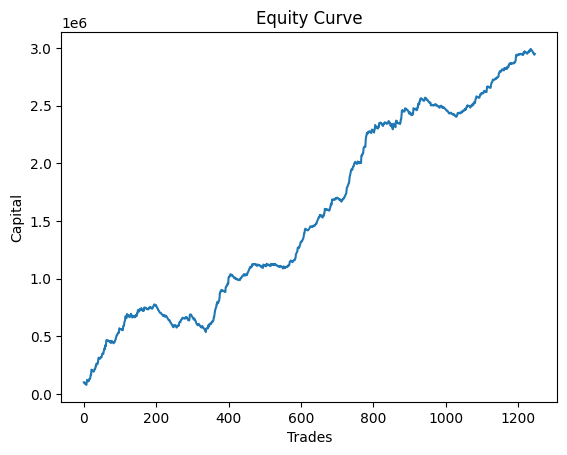


Average Win: 9022.36045402815
Average Loss: -4008.5019593280044
Risk Reward Ratio: 2.250806048137914

Best Trade: 65040.0974135426
Worst Trade: -21974.88302513879

Exit Reason Breakdown:
Exit Reason
UT Sell      1009
Stop Loss     237
Name: count, dtype: int64

Average Return by Exit Type:
Exit Reason
Stop Loss   -6.627082
UT Sell      4.381174
Name: Return %, dtype: float64


In [23]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------- SETTINGS ----------
initial_capital = 100000
trade_size = 100000
stop_loss_pct = 0.05   # 5% stop loss

tickers = [

"HDFCBANK.NS","ICICIBANK.NS","KOTAKBANK.NS","AXISBANK.NS","SBIN.NS",
"BAJFINANCE.NS","BAJAJFINSV.NS","INDUSINDBK.NS","HDFCLIFE.NS","SBILIFE.NS",

"TCS.NS","INFY.NS","HCLTECH.NS","WIPRO.NS","TECHM.NS",
"LTIM.NS","MPHASIS.NS","COFORGE.NS","PERSISTENT.NS","LTI.NS",

"RELIANCE.NS","ONGC.NS","BPCL.NS","IOC.NS","GAIL.NS",
"POWERGRID.NS","NTPC.NS","ADANIGREEN.NS","ADANIPOWER.NS","TATAPOWER.NS",

"HINDUNILVR.NS","ITC.NS","NESTLEIND.NS","BRITANNIA.NS","DABUR.NS",
"GODREJCP.NS","MARICO.NS","COLPAL.NS","PGHH.NS","VBL.NS",

"SUNPHARMA.NS","DRREDDY.NS","DIVISLAB.NS","CIPLA.NS","LUPIN.NS",
"TORNTPHARM.NS","AUROPHARMA.NS","ALKEM.NS","BIOCON.NS","GLENMARK.NS",

"MARUTI.NS","TATAMOTORS.NS","M&M.NS","EICHERMOT.NS","BAJAJ-AUTO.NS",
"HEROMOTOCO.NS","ASHOKLEY.NS","TVSMOTOR.NS","ESCORTS.NS","SONACOMS.NS",

"LT.NS","SIEMENS.NS","ABB.NS","CUMMINSIND.NS","HAVELLS.NS",
"POLYCAB.NS","BOSCHLTD.NS","AIAENG.NS","THERMAX.NS","SKFINDIA.NS",

"TATASTEEL.NS","JSWSTEEL.NS","HINDALCO.NS","VEDL.NS","SAIL.NS",
"NMDC.NS","JINDALSTEL.NS","NATIONALUM.NS","HINDZINC.NS","APLAPOLLO.NS",

"ULTRACEMCO.NS","SHREECEM.NS","AMBUJACEM.NS","ACC.NS","DALBHARAT.NS",

"TITAN.NS","TRENT.NS","DMART.NS","ADANIENT.NS","PAGEIND.NS",

"BHARTIARTL.NS","IDEA.NS","ZEEL.NS","SUNTV.NS","INDIGO.NS"
]

trade_log = []

# ---------- UT BOT ----------
def compute_utbot(df, atr_period=10, multiplier=1):

    df["tr"] = np.maximum(
        df["High"] - df["Low"],
        np.maximum(
            abs(df["High"] - df["Close"].shift()),
            abs(df["Low"] - df["Close"].shift())
        )
    )

    df["atr"] = df["tr"].rolling(atr_period).mean()

    df["upper"] = df["Close"] - multiplier * df["atr"]
    df["lower"] = df["Close"] + multiplier * df["atr"]

    trend = [1]

    for i in range(1, len(df)):
        if df["Close"].iloc[i] > df["lower"].iloc[i-1]:
            trend.append(1)
        elif df["Close"].iloc[i] < df["upper"].iloc[i-1]:
            trend.append(-1)
        else:
            trend.append(trend[-1])

    df["trend"] = trend

    df["buy"] = (df["trend"] == 1) & (df["trend"].shift() == -1)
    df["sell"] = (df["trend"] == -1) & (df["trend"].shift() == 1)

    return df


# ---------- BACKTEST ----------
for ticker in tickers:

    print("Testing:", ticker)

    stock = yf.Ticker(ticker)
    df = stock.history(period="5y")

    if df.empty:
        continue

    df = compute_utbot(df)

    info = stock.info
    eps = info.get("trailingEps")

    if eps is None:
        continue

    growth = info.get("earningsQuarterlyGrowth")
    if growth is None:
        growth = 0.05

    g = min(growth * 100, 15)
    intrinsic = eps * (8.5 + 2 * g)

    position = False
    shares = 0

    for i, row in df.iterrows():

        price = row["Close"]

        # ---------- BUY ----------
        if not position and row["buy"]:
            if price < intrinsic:
                shares = trade_size / price
                entry_price = price
                entry_date = i
                position = True

        # ---------- SELL ----------
        elif position:

            stop_price = entry_price * (1 - stop_loss_pct)

            if price <= stop_price:
                exit_price = price
                exit_reason = "Stop Loss"

            elif row["sell"]:
                exit_price = price
                exit_reason = "UT Sell"

            else:
                continue

            exit_date = i

            profit = (exit_price - entry_price) * shares

            trade_log.append({
                "Stock": ticker,
                "Entry Date": entry_date,
                "Exit Date": exit_date,
                "Entry": entry_price,
                "Exit": exit_price,
                "Profit": profit,
                "Return %": (exit_price / entry_price - 1) * 100,
                "Exit Reason": exit_reason
            })

            position = False


# ---------- RESULTS ----------
trades = pd.DataFrame(trade_log)

print("\nTotal Trades:", len(trades))

if len(trades) > 0:
    win_rate = len(trades[trades["Profit"] > 0]) / len(trades)
    print("Win Rate:", win_rate)

total_profit = trades["Profit"].sum()
final_capital = initial_capital + total_profit

print("\nInitial Capital:", initial_capital)
print("Final Capital:", final_capital)
print("Total Return %:", (final_capital / initial_capital - 1) * 100)

# ---------- TRADE LOG TABLE ----------
trades = trades.sort_values("Exit Date")

# Add cumulative profit & equity
trades["Cumulative Profit"] = trades["Profit"].cumsum()
trades["Equity"] = initial_capital + trades["Cumulative Profit"]

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

print("\nFULL TRADE LOG:\n")
print(trades)

# ---------- SAVE CSV ----------
trades.to_csv("trade_log.csv", index=False)
print("\nTrade log saved as trade_log.csv")

# ---------- EQUITY CURVE ----------
equity = [initial_capital]

for p in trades["Profit"]:
    equity.append(equity[-1] + p)

plt.figure()
plt.plot(equity)
plt.title("Equity Curve")
plt.xlabel("Trades")
plt.ylabel("Capital")
plt.show()

# ---------- RISK / REWARD ----------
avg_win = trades[trades["Profit"] > 0]["Profit"].mean()
avg_loss = trades[trades["Profit"] < 0]["Profit"].mean()

print("\nAverage Win:", avg_win)
print("Average Loss:", avg_loss)

if avg_loss != 0:
    print("Risk Reward Ratio:", abs(avg_win / avg_loss))

# ---------- EXTRA INSIGHTS ----------
print("\nBest Trade:", trades["Profit"].max())
print("Worst Trade:", trades["Profit"].min())

print("\nExit Reason Breakdown:")
print(trades["Exit Reason"].value_counts())

print("\nAverage Return by Exit Type:")
print(trades.groupby("Exit Reason")["Return %"].mean())